In [2]:
import scanpy as sc
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import decoupler

import os
import sys
import logging
import warnings
from utils import *

/ocean/projects/cis240075p/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/ocean/projects/cis240075p/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/ocean/projects/cis240075p/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [3]:
# load file path from ocean
adata_infile = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/All_Cell_Types.h5ad'
adata_infile_fiber = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/Myofiber_scsn_RNA.h5ad'
adata_male_file = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp/myofibers_male.h5ad'
adata_female_file = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp/myofibers_female.h5ad'
out_tmp = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp'

In [70]:
adata_male = sc.read_h5ad(adata_male_file)
adata_female = sc.read_h5ad(adata_female_file)

In [71]:
adata_fiber = sc.read_h5ad(adata_infile_fiber)

# Myofiber analysis

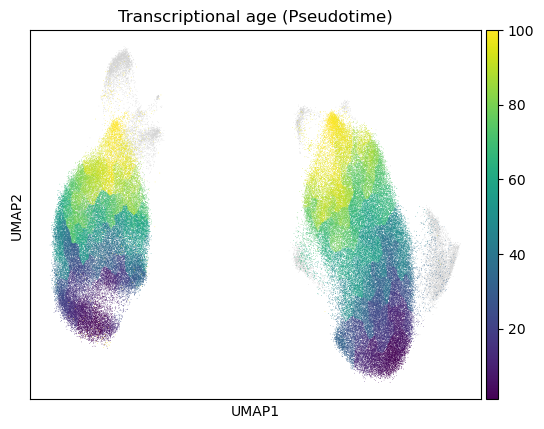

In [75]:
sc.pl.umap(adata_fiber, color=['Pseudotime'], title='Transcriptional age (Pseudotime)')

In [5]:
adata_female

AnnData object with n_obs × n_vars = 76546 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'DNA_DAMAGE_CHECKPOINT', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR', 'REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS', 'GOBP_FATTY_ACID_BETA_OXIDATION', 'KEGG_CITRATE_CYCLE_TCA_CYCLE', 'KEGG_GLYCOLYSIS_GLUCONEOGENESIS', 'KEGG_OXIDATIVE_PHOSPHORYLATION', 'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM', 'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM', 'Atrophy Pathway'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'Sex_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors

In [6]:
# count the number of cells in each age
display(adata_male.obs['sample'].value_counts())

sample
YM3    20055
YM1    16829
OM5    11986
P5      8992
OM7     5693
P13     2949
YM4     2843
OM3     1834
P23     1223
P17     1215
P29      454
OM4      275
Name: count, dtype: int64

## Molecular age (pseudotime based) of each sample

/tmp/ipykernel_101622/2432330064.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_summary_df_all_annotations = obs_df_valid_pt.groupby(['sample', annotation_col]).agg(


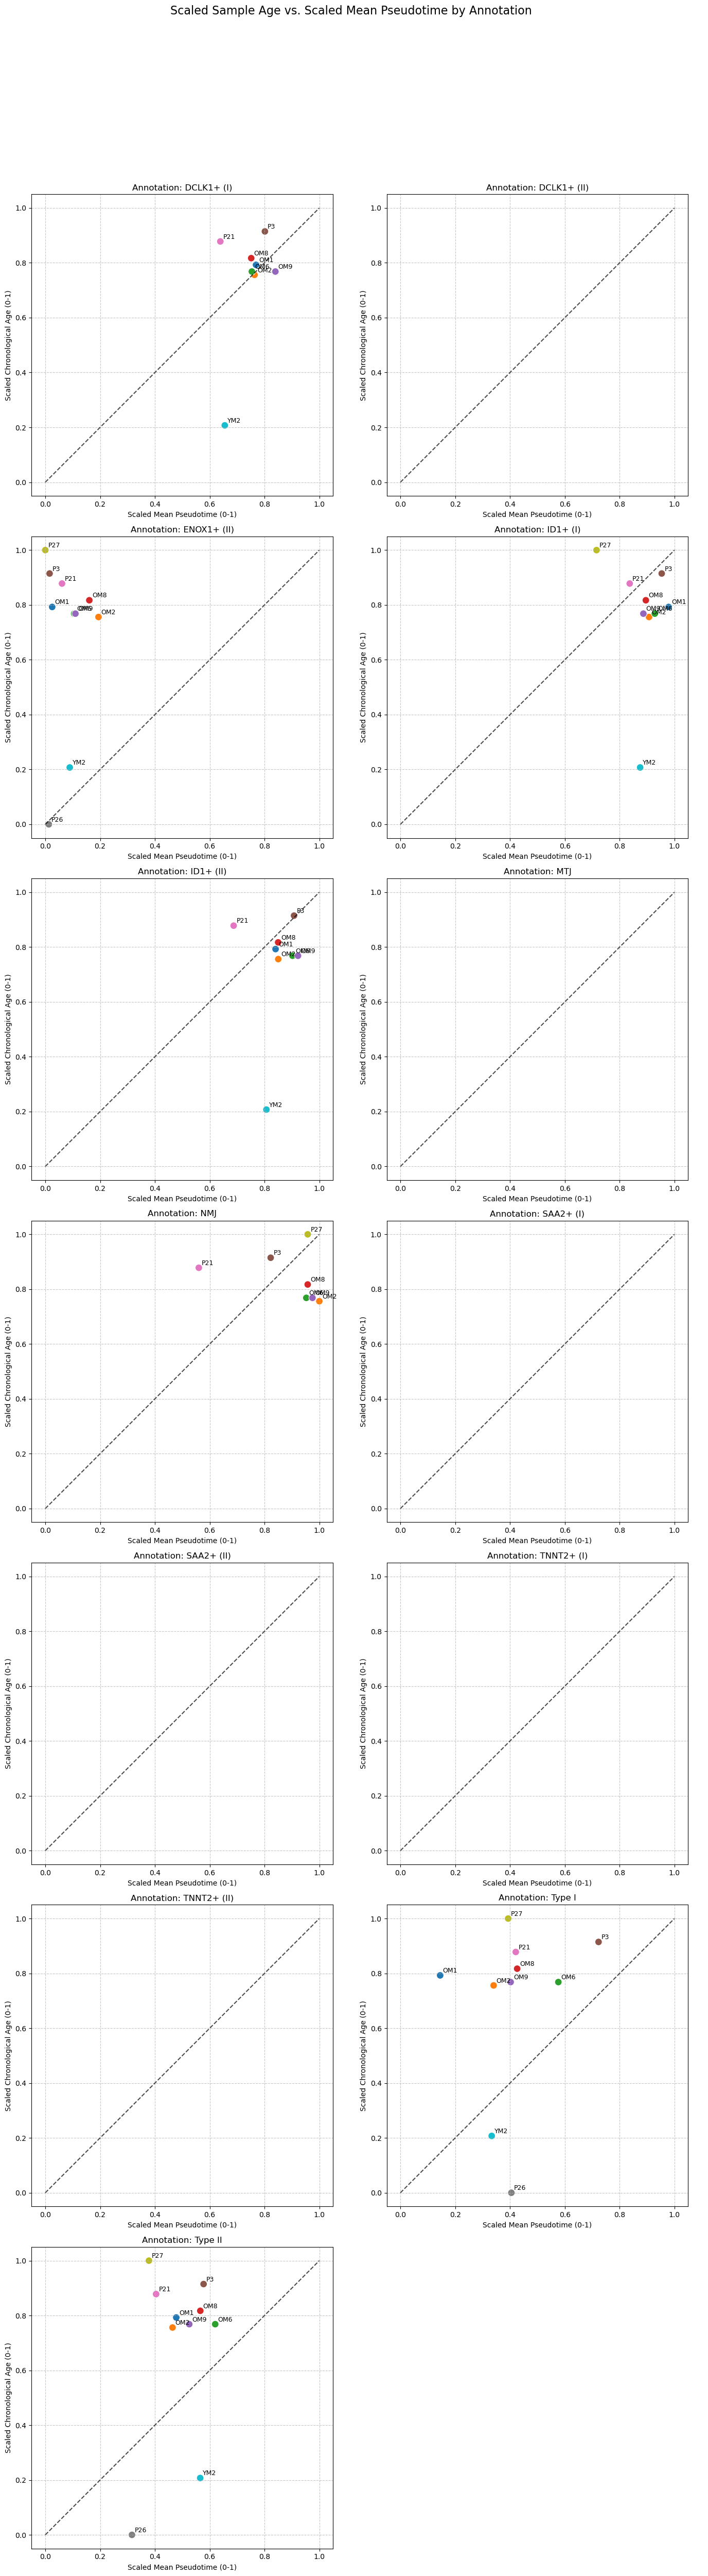

In [218]:
fig_by_annotation, summary_df_all = plot_age_vs_pseudotime_by_annotation(
    adata_female,
    annotation_col='Annotation', # Make sure this column name is correct
    point_size=100,
    n_subplot_cols=2 # Or 1 if you only have 'Type I' and 'Type II' and want them stacked
)

# AUCell activity scoring of specific pathways

In [10]:
# load geneset of interest
# geneset_gmt = ["/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/GOBP_FATTY_ACID_BETA_OXIDATION.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_CITRATE_CYCLE_TCA_CYCLE.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_GLYCOLYSIS_GLUCONEOGENESIS.v2024.1.Hs.gmt",
#                "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_OXIDATIVE_PHOSPHORYLATION.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM.v2024.1.Hs.gmt"]
# geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt)
geneset_gmt = ["/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_damage_response/DNA_DAMAGE_CHECKPOINT.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_damage_response/GOBP_DNA_DAMAGE_RESPONSE.v2024.1.Hs.gmt", 
               "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_damage_response/REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS.v2024.1.Hs.gmt"]
geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt, geneset_name='source', genesymbol_name='target')
# get the number of rows in each unique geneset
geneset_size = geneset_df['source'].value_counts()
display(geneset_size)
display(geneset_df)
# custom_atrophy_pathway = ["UBB","UBC","FBXO32","TRIM63","MDM2","FBXO30","CAMK2B","TIE1","PSMA1","PSMA2","PSMA3","PSMA4","PSMA5","PSMA6","PSMA7","PSMB1","PSMB2","PSMB3","PSMB4","FBXO21","FBXO31","NEDD4","UBE2B","UBE2G1","UBE2J1","CTSL","CTSV","BNIP3","DEPP1","GABARAPL1","MAP1LC3","RETREG1","SQSTM1","CAPN1","CAPN2","ATF4","FOXO1","FOXO3A","HDAC9","RUNX1","AMPD3","CHRNA1","CDKN1A"]
# geneset_df = pd.DataFrame({'geneset': "Atrophy Pathway (PMID: 31325479)", 'genesymbol': custom_atrophy_pathway})
# geneset_df


source
GOBP_DNA_DAMAGE_RESPONSE                906
REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS     68
DNA_DAMAGE_CHECKPOINT                    20
Name: count, dtype: int64

,source,target
0,DNA_DAMAGE_CHECKPOINT,ATR
1,DNA_DAMAGE_CHECKPOINT,ATRIP
2,DNA_DAMAGE_CHECKPOINT,BRSK1
3,DNA_DAMAGE_CHECKPOINT,CCNA2
4,DNA_DAMAGE_CHECKPOINT,CHEK1
...,...,...
989,REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS,TP53
990,REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS,UBA52
991,REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS,UBB
992,REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS,UBC


In [12]:
%%time
decoupler.mt.aucell(
    adata_male,
    geneset_df,
    raw=False,
    verbose=True
)

2025-11-11 19:25:16 | [INFO] aucell - Running aucell
2025-11-11 19:25:16 | [INFO] Extracted omics mat with 74348 rows (observations) and 48355 columns (features)
2025-11-11 19:25:17 | [WARNING] 5848 features of mat are empty, they will be removed
2025-11-11 19:25:18 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2025-11-11 19:25:18 | [INFO] Network has 938 unique features and 3 unique sources
2025-11-11 19:25:18 | [INFO] aucell - calculating 3 AUCs for 42507 targets across 74348 observations, categorizing features at rank=2126


  0%|          | 0/74348 [00:00<?, ?it/s]

2025-11-11 19:26:34 | [INFO] aucell - done


CPU times: user 13min 15s, sys: 37min 16s, total: 50min 31s
Wall time: 1min 17s


In [13]:
dna_damage_pathways = [
    "DNA_DAMAGE_CHECKPOINT",
    "GOBP_DNA_DAMAGE_RESPONSE",
    "REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS"
]
metabolic_pathways = [
    "GOBP_FATTY_ACID_BETA_OXIDATION",
    "KEGG_CITRATE_CYCLE_TCA_CYCLE",
    "KEGG_GLYCOLYSIS_GLUCONEOGENESIS",
    "KEGG_OXIDATIVE_PHOSPHORYLATION",
    "REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM",
    "REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM"
]
#adata_male.obs["Atrophy Pathway"] = adata_male.obsm["aucell_estimate"]["Atrophy Pathway (PMID: 31325479)"]

### Plot samples ordered by score to select outliers for bar-plot comparitive analysis between cohorts

In [43]:
# save adata
adata_male.write_h5ad(os.path.join(out_tmp, 'myofibers_male.h5ad'))

# Downsample myofibers to include size matched old and young cohorts (n=2)

In [76]:
adata_female_downsampled = adata_female[adata_female.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM9'])].copy()
adata_male_downsampled = adata_male[adata_male.obs['sample'].isin(['P13', 'P5', 'OM5', 'OM7'])].copy()

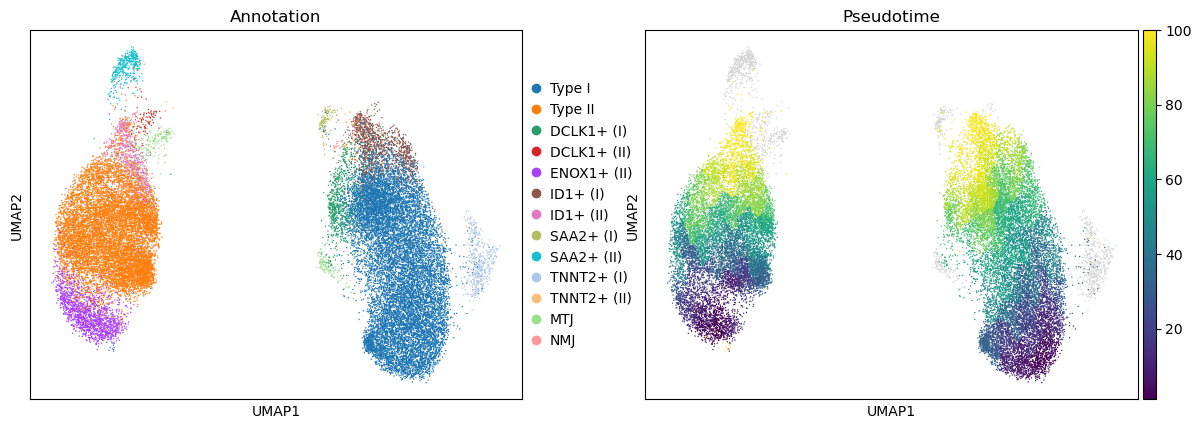

In [84]:
sc.pl.umap(adata_male_downsampled, color=['Annotation','Pseudotime'])

In [77]:
# get a df of sample ID, sample score per cell type and age
sample_scores = adata_male_downsampled.obs[['sample','age', 'Annotation']+dna_damage_pathways].copy()
# average scores per sample and group by Annotation
sample_scores_avg = sample_scores.groupby(['sample', 'Annotation']).mean().reset_index()
sample_scores_avg.head()

/tmp/ipykernel_42026/932079569.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_scores_avg = sample_scores.groupby(['sample', 'Annotation']).mean().reset_index()


,sample,Annotation,age,DNA_DAMAGE_CHECKPOINT,GOBP_DNA_DAMAGE_RESPONSE,REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS
0,OM5,Type I,82.0,0.086170,0.085863,0.071091
1,OM5,Type II,82.0,0.069601,0.083622,0.074343
2,OM5,DCLK1+ (I),82.0,0.080726,0.086028,0.071880
3,OM5,DCLK1+ (II),82.0,0.069796,0.084111,0.071703
4,OM5,ENOX1+ (II),82.0,0.072478,0.084562,0.071428


## Plots wrt age

In [78]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = adata_male_downsampled.obs[['sample', 'age', 'Annotation', 'Pseudotime'] + dna_damage_pathways].copy()
# geneset_sizes_data = {
#     'KEGG_OXIDATIVE_PHOSPHORYLATION': 132,
#     'GOBP_FATTY_ACID_BETA_OXIDATION': 75,
#     'KEGG_GLYCOLYSIS_GLUCONEOGENESIS': 62,
#     'KEGG_CITRATE_CYCLE_TCA_CYCLE': 31,
#     'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM': 21,
#     'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM': 14
# }
geneset_sizes_data = {
    'GOBP_DNA_DAMAGE_RESPONSE': 906,
    'REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS': 68,
    'DNA_DAMAGE_CHECKPOINT': 20
}
geneset_sizes_series = pd.Series(geneset_sizes_data)


In [79]:
#subset to a fiber type
cell_level_scores_df_subset = cell_level_scores_df[cell_level_scores_df['Annotation'] == 'Type II']
display(cell_level_scores_df_subset)

,sample,age,Annotation,Pseudotime,DNA_DAMAGE_CHECKPOINT,GOBP_DNA_DAMAGE_RESPONSE,REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS
CELL490_N1_1_1_1_1_4_1,OM7,82,Type II,NaN,0.055590,0.081213,0.010666
CELL968_N1_1_1_1_1_4_1,OM7,82,Type II,22.0,0.073789,0.063678,0.025706
CELL333_N1_1_1_1_1_4_1,OM7,82,Type II,NaN,0.103025,0.096652,0.030714
CELL186_N2_1_1_1_1_4_1,OM7,82,Type II,82.0,0.121106,0.074883,0.042793
CELL358_N1_1_1_1_1_4_1,OM7,82,Type II,84.0,0.061144,0.078512,0.049941
...,...,...,...,...,...,...,...
CELL2943_N1_2_2_10_1,P5,45,Type II,12.0,0.118317,0.061115,0.076382
CELL3713_N1_2_2_10_1,P5,45,Type II,41.0,0.018152,0.048675,0.024956
CELL4033_N1_2_2_10_1,P5,45,Type II,31.0,0.080950,0.049348,0.037891
CELL3669_N1_2_2_10_1,P5,45,Type II,51.0,0.067431,0.066288,0.076225


2025-11-11 21:48:41 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/tmp/ipykernel_42026/74839251.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  violin = sns.violinplot(
2025-11-11 21:48:41 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-11 21:48:41 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-11 21:48:41 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-11 21:48:41 | [INFO] Using categorical units to plot a list of strings that are all pars

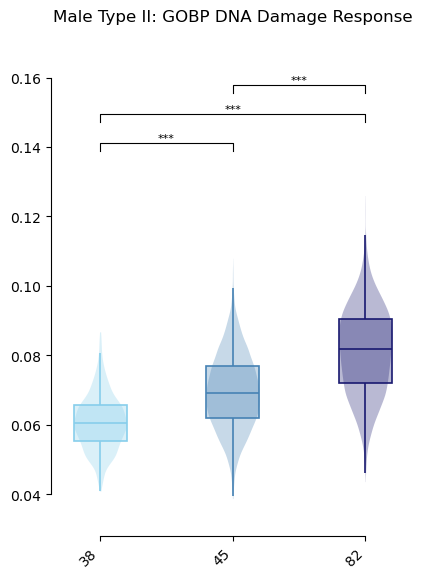

<Figure size 640x480 with 0 Axes>

In [82]:
plot_data = cell_level_scores_df_subset.copy()
plot_data['age'] = plot_data['age'].astype(str)

# custom_colors = {
#     '17': '#C4A0E7',
#     '34': '#7B1FA2',   
#     '80': '#3D1F5C'
# }

custom_colors = {
    '38': '#87CEEB',  # Sky blue
    '45': '#4682B4',  # Steel blue
    '82': '#191970'  # Midnight blue
}

fig = plot_violin_box_combo(
    data=plot_data,
    x_var='age',
    y_var='GOBP_DNA_DAMAGE_RESPONSE',
    title='Male Type II: GOBP DNA Damage Response',
    x_ticks=['38','45','82'],
    palette=custom_colors,
    rotation=45,
    show_scatter=False
)

# Display the plot
from IPython.display import display
display(fig)
# save as pdf 
#fig.savefig('/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver/figures/cellage_scores.pdf', bbox_inches='tight')

## Plots wrt pseudotime

In [62]:
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter, PillowWriter
from IPython.display import HTML, display
from IPython.display import FileLink

def create_animated_pathway_plot(
    df_cell_level: pd.DataFrame,
    score_cols: list,
    pseudotime_key: str = 'Pseudotime',
    group_by_key: str = 'Annotation',
    smoothing_method: str = 'gaussian',
    smoothing_strength: float = 120.0,
    geneset_sizes: pd.Series = None,
    groups_to_plot: list = None,
    colors_dict: dict = None,
    legend_labels_map: dict = None,
    n_subplot_cols: int = 2,
    figsize_per_subplot: tuple = (7, 4),
    # Animation parameters
    nframes: int = 200,
    fps: int = 30,
    dot_size: int = 150,
    output_file: str = 'pathway_animation.mp4',
    use_gif: bool = False  # Set True if ffmpeg doesn't work
):
    """
    Creates animated pathway plots with moving dots.
    """
    
    print("Starting animation creation...")
    
    # Validate inputs
    required_cols = score_cols + [pseudotime_key, group_by_key]
    missing = [c for c in required_cols if c not in df_cell_level.columns]
    if missing:
        print(f"ERROR: Missing columns: {missing}")
        return None
    
    # Setup figure
    num_scores = len(score_cols)
    n_subplot_rows = (num_scores + n_subplot_cols - 1) // n_subplot_cols
    
    fig, axes = plt.subplots(
        n_subplot_rows, n_subplot_cols,
        figsize=(figsize_per_subplot[0] * n_subplot_cols, 
                figsize_per_subplot[1] * n_subplot_rows),
        squeeze=False
    )
    axes = axes.flatten()
    
    # Store animation data
    all_lines_data = []
    
    # Plot each pathway
    for subplot_idx, score_col in enumerate(score_cols):
        ax = axes[subplot_idx]
        
        # Get data for this pathway
        plot_df = df_cell_level[[score_col, pseudotime_key, group_by_key]].copy()
        plot_df = plot_df.dropna()
        
        if plot_df.empty:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            continue
        
        # Determine groups
        if groups_to_plot:
            groups = [g for g in groups_to_plot if g in plot_df[group_by_key].unique()]
        else:
            groups = sorted(plot_df[group_by_key].unique())
        
        # Plot each group
        for group_idx, group in enumerate(groups):
            group_data = plot_df[plot_df[group_by_key] == group].copy()
            group_data = group_data.sort_values(pseudotime_key)
            
            if len(group_data) < 2:
                continue
            
            x_vals = group_data[pseudotime_key].values
            y_vals = group_data[score_col].values
            
            # Apply smoothing
            if smoothing_method == 'gaussian' and len(y_vals) > 10:
                try:
                    y_vals_smooth = gaussian_filter1d(y_vals, sigma=smoothing_strength)
                except:
                    y_vals_smooth = y_vals
                    print(f"Warning: Smoothing failed for {group} in {score_col}")
            else:
                y_vals_smooth = y_vals
            
            # Get color
            color = colors_dict.get(group, f'C{group_idx}') if colors_dict else f'C{group_idx}'
            label = legend_labels_map.get(group, group) if legend_labels_map else group
            
            # Plot line
            line, = ax.plot(x_vals, y_vals_smooth, color=color, linewidth=1.5, 
                           label=label, alpha=0.8)
            
            # Create dot for animation (initially invisible)
            dot = ax.scatter([], [], s=dot_size, color=color, 
                           zorder=100, edgecolors='white', linewidths=2)
            
            # Store data for animation
            all_lines_data.append({
                'ax': ax,
                'x': x_vals,
                'y': y_vals_smooth,
                'dot': dot,
                'color': color
            })
        
        # Format subplot
        title = score_col.replace('_', ' ')
        if geneset_sizes is not None and score_col in geneset_sizes.index:
            title += f"\n(n={int(geneset_sizes[score_col])})"
        
        ax.set_title(title, fontsize=12)
        ax.set_xlabel(r"Pseudotime $\rightarrow$", fontsize=10)
        ax.set_ylabel("Score", fontsize=10)
        ax.legend(loc='upper left', frameon=False, fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(num_scores, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    print(f"Figure created with {len(all_lines_data)} animated lines")
    
    # Create animation
    def init():
        """Initialize animation"""
        for line_data in all_lines_data:
            line_data['dot'].set_offsets(np.empty((0, 2)))
        return [ld['dot'] for ld in all_lines_data]
    
    def animate(frame):
        """Update function for each frame"""
        progress = frame / (nframes - 1)
        
        for line_data in all_lines_data:
            x = line_data['x']
            y = line_data['y']
            
            if len(x) > 0:
                # Find position along line
                idx = int(progress * (len(x) - 1))
                idx = min(idx, len(x) - 1)
                
                # Update dot position
                line_data['dot'].set_offsets([[x[idx], y[idx]]])
        
        return [ld['dot'] for ld in all_lines_data]
    
    # Create the animation
    print(f"Creating animation with {nframes} frames at {fps} fps...")
    anim = animation.FuncAnimation(
        fig, animate, init_func=init,
        frames=nframes, interval=1000/fps,
        blit=True, repeat=True
    )
    
    # Save animation
    try:
        if use_gif:
            # Use GIF if ffmpeg doesn't work
            output_file = output_file.replace('.mp4', '.gif')
            print(f"Saving as GIF to {output_file}...")
            writer = PillowWriter(fps=fps)
            anim.save(output_file, writer=writer, dpi=100)
            print(f"✓ GIF saved successfully!")
        else:
            # Try MP4
            print(f"Saving as MP4 to {output_file}...")
            writer = FFMpegWriter(fps=fps, codec='mpeg4', bitrate=1800)
            anim.save(output_file, writer=writer, dpi=100)
            print(f"✓ MP4 saved successfully!")
        
        # Create download link
        display(FileLink(output_file))
        print(f"\nAnimation saved! Click the link above to download.")
        
        return anim, fig
        
    except Exception as e:
        print(f"\n❌ Error saving animation: {e}")
        print("\nTrying alternative methods...")
        
        # Try GIF as fallback
        try:
            output_file_gif = output_file.replace('.mp4', '.gif')
            print(f"Attempting GIF format: {output_file_gif}")
            writer = PillowWriter(fps=fps)
            anim.save(output_file_gif, writer=writer, dpi=100)
            print(f"✓ GIF saved successfully!")
            display(FileLink(output_file_gif))
            return anim, fig
        except Exception as e2:
            print(f"❌ GIF also failed: {e2}")
            print("\n🔧 TROUBLESHOOTING:")
            print("1. Check if ffmpeg is installed: !which ffmpeg")
            print("2. Install ffmpeg: conda install ffmpeg")
            print("3. Or use: use_gif=True in the function call")
            print("\n📺 Displaying animation in notebook instead...")
            
            # Show in notebook as last resort
            return HTML(anim.to_jshtml()), fig


⚠ FFmpeg not found - will use GIF format instead

Starting animation creation...
Figure created with 2 animated lines
Creating animation with 200 frames at 30 fps...


2025-11-11 21:54:13 | [INFO] Animation.save using <class 'matplotlib.animation.PillowWriter'>


Saving as GIF to pathway_animation.gif...
✓ GIF saved successfully!


/ocean/projects/cis240075p/asachan/bio_informatics_analysis/SKM_multimodal_ageing_analysis/py_scripts/pathway_animation.gif


Animation saved! Click the link above to download.

Animation creation complete!


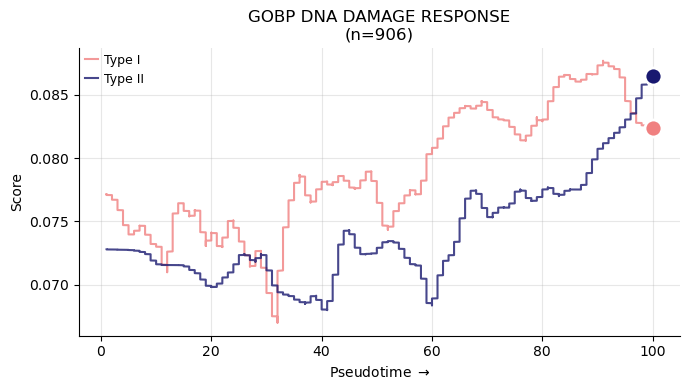

In [83]:
# ====== USAGE ======
plot_colors = {'Type I': '#F08080', 'Type II': '#191970'}
legend_labels = {'Type I': 'Type I', 'Type II': 'Type II'}

# First, let's check if ffmpeg is available
import subprocess
try:
    result = subprocess.run(['ffmpeg', '-version'], 
                          capture_output=True, text=True, timeout=5)
    print("✓ FFmpeg is installed")
    use_gif_format = False
except:
    print("⚠ FFmpeg not found - will use GIF format instead")
    use_gif_format = True

print()


# Your list of score columns
score_cols_to_plot = ['GOBP_DNA_DAMAGE_RESPONSE']

# Create animation
anim_result = create_animated_pathway_plot(
    df_cell_level=cell_level_scores_df,
    score_cols=score_cols_to_plot,
    pseudotime_key='Pseudotime',
    group_by_key='Annotation',
    smoothing_method='gaussian',
    smoothing_strength=120.0,  # Smoother lines
    geneset_sizes=geneset_sizes_series,
    groups_to_plot=['Type I', 'Type II'],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    n_subplot_cols=1,
    figsize_per_subplot=(7, 4),
    nframes=200,  # More frames = smoother
    fps=30,
    dot_size=150,
    output_file='pathway_animation.mp4',
    use_gif=use_gif_format  # Will auto-detect
)

print("\n" + "=" * 60)
print("Animation creation complete!")
print("=" * 60)

In [26]:
# # Colors for 'Type I' and 'Type II'
# plot_colors = {'Type I': '#F08080', 'Type II': '#191970'}
# legend_labels = {'Type I': 'Type I', 'Type II': 'Type II'}

# plot_multi_smoothed_lines_from_df(
#     df_cell_level=cell_level_scores_df,
#     score_cols=score_cols_to_plot,
#     pseudotime_key='Pseudotime',
#     group_by_key='Annotation',
#     smoothing_method='gaussian',          # Specify method
#     smoothing_strength=70.0,             # Fraction for LOWESS (e.g., 0.05 to 0.2)
#     geneset_sizes=geneset_sizes_series,
#     groups_to_plot=['Type I', 'Type II'],
#     colors_dict=plot_colors,
#     legend_labels_map=legend_labels,
#     n_subplot_cols=2,
#     figsize_per_subplot=(7, 4),
#     common_xlabel=r"Pseudotime $\rightarrow$",
#     common_ylabel="Score",
#     common_ylim=None, common_xticks_list=None, common_yticks_list=None,
#     common_legend_loc=(0.02, 0.85), common_line_kwargs={'linewidth': 1.0},
#     main_figure_title=None,
#     debug_prints_for_subp_plot_func=False
# )


# DEGs and gsea pathway analysis

#### Do size matching to get a more balanced sample size for DEG significance

In [151]:
adata_female_downsampled.obs['age_pop'] = pd.Categorical(adata_female_downsampled.obs['age_pop'], categories=["old_pop", "young_pop"], ordered=True)

In [165]:
bdata = adata_female_downsampled[adata_female_downsampled.obs.Annotation == "Type I"].copy()
bdata

AnnData object with n_obs × n_vars = 23407 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'DNA_DAMAGE_CHECKPOINT', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR', 'REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS', 'GOBP_FATTY_ACID_BETA_OXIDATION', 'KEGG_CITRATE_CYCLE_TCA_CYCLE', 'KEGG_GLYCOLYSIS_GLUCONEOGENESIS', 'KEGG_OXIDATIVE_PHOSPHORYLATION', 'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM', 'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM', 'Atrophy Pathway'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'Sex_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors

In [166]:
sc.tl.rank_genes_groups(bdata,
                        groupby='age_pop',
                        use_raw=False,
                        method='wilcoxon',
                        groups=["old_pop"],
                        reference='young_pop')

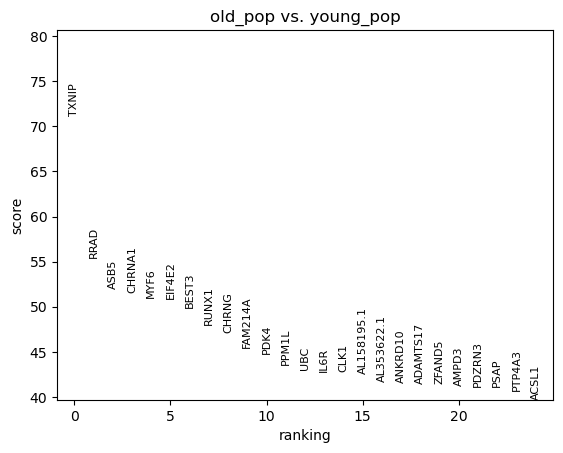

In [167]:
sc.pl.rank_genes_groups(bdata, n_genes=25, sharey=False)

In [168]:
# get deg result
result = bdata.uns['rank_genes_groups']
groups = result['names'].dtype.names
degs = pd.DataFrame(
    {group + '_' + key: result[key][group]
    for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
degs.head()

,old_pop_names,old_pop_scores,old_pop_pvals,old_pop_pvals_adj,old_pop_logfoldchanges
0,TXNIP,71.215881,0.0,0.0,3.347214
1,RRAD,55.443909,0.0,0.0,2.819716
2,ASB5,51.990772,0.0,0.0,2.270588
3,CHRNA1,51.537991,0.0,0.0,6.147987
4,MYF6,50.994728,0.0,0.0,3.057939


In [172]:
# subset up or down regulated genes
degs_sig = degs[degs.old_pop_pvals_adj < 0.01]
degs_up = degs_sig[degs_sig.old_pop_logfoldchanges > 0]
degs_dw = degs_sig[degs_sig.old_pop_logfoldchanges < 0]

In [173]:
degs_up.shape

(6447, 5)

In [174]:
degs_dw.shape

(791, 5)

In [175]:
enr_up = gp.enrichr(degs_up.old_pop_names,
                    gene_sets='GO_Biological_Process_2025',
                    outdir=None)

In [176]:
enr_up.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Intracellular Protein Transport (GO:0006886),185/326,3.740609e-20,1.856838e-16,0,0,2.810173,1.257059e+02,IPO13;VPS29;MTCH1;IPO11;NDUFA13;NUP107;CSE1L;P...
1,GO_Biological_Process_2025,Macroautophagy (GO:0016236),101/162,2.931945e-15,7.277087e-12,0,0,3.520204,1.177970e+02,RETREG3;PJVK;AUP1;PHB2;ZFYVE1;ZFYVE26;TBK1;LAM...
2,GO_Biological_Process_2025,Ubiquitin-Dependent Protein Catabolic Process ...,224/455,2.125642e-14,3.517229e-11,0,0,2.075896,6.535361e+01,IPP;KEAP1;UBE2L3;DCAF1;PSMD9;HERC4;PSMD6;PSMD7...
3,GO_Biological_Process_2025,Proteasomal Protein Catabolic Process (GO:0010...,186/372,5.860062e-13,7.272337e-10,0,0,2.134962,6.013217e+01,MIDN;UBXN2B;UBE3D;UBXN2A;UBE2D3;IPP;KEAP1;UBE2...
4,GO_Biological_Process_2025,Protein Ubiquitination (GO:0016567),180/369,2.058578e-11,2.043756e-08,0,0,2.030895,4.997306e+01,UBE3D;UBE2D2;FBXO28;UBE2D3;KEAP1;UBE2D1;UBE3B;...
...,...,...,...,...,...,...,...,...,...,...
4959,GO_Biological_Process_2025,Adenylate Cyclase-Inhibiting G Protein-Coupled...,2/56,9.999964e-01,9.999966e-01,0,0,0.077574,2.822864e-07,GNAI3;PRKCA
4960,GO_Biological_Process_2025,Sensory Perception of Bitter Taste (GO:0050913),1/38,9.999965e-01,9.999966e-01,0,0,0.056670,1.997060e-07,BPNT1
4961,GO_Biological_Process_2025,"GPCR Sgnlng Pway, Coupled to Cyclic Nucleotide...",1/50,9.999965e-01,9.999966e-01,0,0,0.042754,1.492117e-07,DHX34
4962,GO_Biological_Process_2025,Detection of Chemical Stimulus Involved in Sen...,1/41,9.999966e-01,9.999966e-01,0,0,0.052408,1.760014e-07,BPNT1


<>:2: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_101622/3343746717.py:2: SyntaxWarning: invalid escape sequence '\('
  enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]


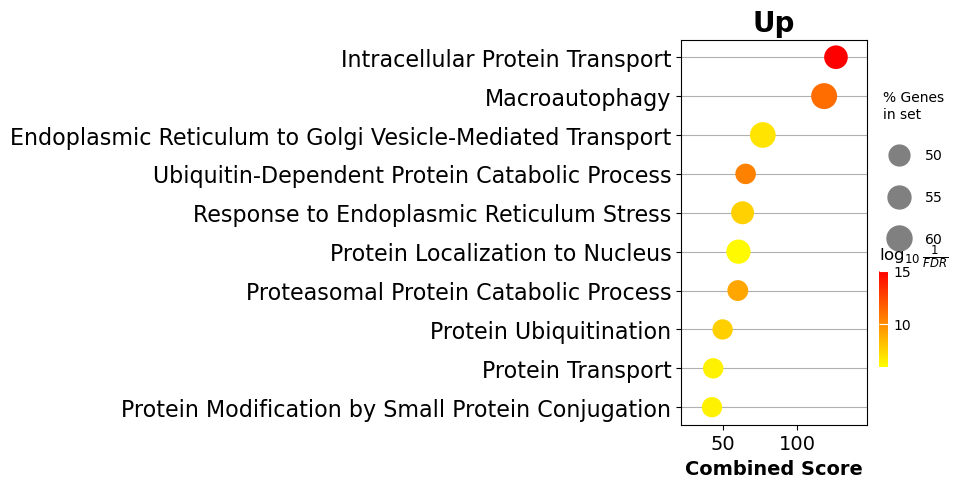

In [177]:
# dotplot
enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_up.res2d, figsize=(3,5), title="Up", cmap = plt.cm.autumn_r)
plt.show()

In [178]:
enr_dw = gp.enrichr(degs_dw.old_pop_names,
                    gene_sets='GO_Biological_Process_2025',
                    outdir=None)

In [179]:
enr_dw.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Muscle Contraction (GO:0006936),31/97,3.293860e-20,9.084467e-17,0,0,11.830801,530.725513,RYR1;MYLK2;ROCK2;LMOD1;MYL6B;MYOM2;RYR3;CLCN1;...
1,GO_Biological_Process_2025,Actomyosin Structure Organization (GO:0031032),29/85,6.875970e-20,9.481963e-17,0,0,13.016428,574.332546,MYOM1;ROCK2;LMOD1;MYOM2;MYPN;MYOM3;EPB41L4B;EP...
2,GO_Biological_Process_2025,Myofibril Assembly (GO:0030239),23/51,2.734655e-19,2.514060e-16,0,0,20.515392,876.891708,MYOM1;MYBPC1;MYBPC2;ADPRHL1;ACTN2;TMOD4;TPM1;L...
3,GO_Biological_Process_2025,Sarcomere Organization (GO:0045214),18/34,5.635273e-17,3.885521e-14,0,0,27.932891,1045.106361,MYOM1;MYBPC1;MYBPC2;TPM1;MYOM2;MYPN;MYOM3;OBSC...
4,GO_Biological_Process_2025,Striated Muscle Contraction (GO:0006941),18/55,1.684618e-12,9.292354e-10,0,0,12.065872,327.099536,RYR1;MYLK2;DTNA;PGAM2;TNNC2;TPM1;STAC3;ATP1A2;...
...,...,...,...,...,...,...,...,...,...,...
2753,GO_Biological_Process_2025,Adenylate Cyclase-Activating G Protein-Coupled...,1/153,9.979641e-01,9.988350e-01,0,0,0.158703,0.000323,ADCY2
2754,GO_Biological_Process_2025,DNA Metabolic Process (GO:0006259),4/302,9.980277e-01,9.988350e-01,0,0,0.322540,0.000637,RPS3;INO80;TOP1;SMC1A
2755,GO_Biological_Process_2025,Lipid Metabolic Process (GO:0006629),3/259,9.981107e-01,9.988350e-01,0,0,0.281860,0.000533,PER2;ACSL3;PPARA
2756,GO_Biological_Process_2025,Defense Response to Bacterium (GO:0042742),2/221,9.986971e-01,9.990593e-01,0,0,0.219803,0.000287,TFEB;OPTN


<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_101622/1711771011.py:1: SyntaxWarning: invalid escape sequence '\('
  enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]


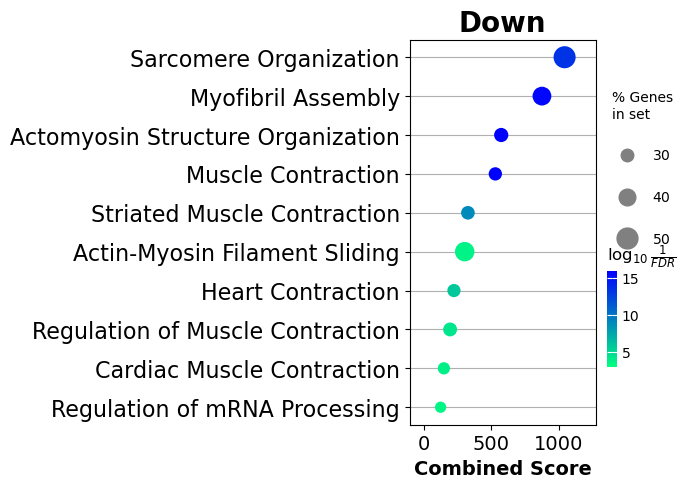

In [180]:
enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_dw.res2d,
           figsize=(3,5),
           title="Down",
           cmap = plt.cm.winter_r,
           size=5)
plt.show()